# RMP Plotting Pipeline by Genotype

This notebook runs the workflow in order:
1. Read the master file
2. Optionally append RMP values from ABF files
3. Build the pivot table
4. Plot grouped RMP with significance
5. Plot change from baseline
6. Plot histogram views
7. Plot the final membrane-change bar chart from sweep-level data

## Required Master File Columns
- `filepath`
- `ID`
- `genotype`
- `condition`
- `comment` (optional, but recommended; rows with `exclude` are removed)

The notebook keeps the condition labels in the data as needed for the plotting cells, and the sweep-level plots use ABF-derived measurements to match the older notebook.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyabf
import pingouin as pg
from scipy import stats
from statsmodels.stats.anova import AnovaRM

sns.set_context('poster')

In [2]:
MASTER_FILE = '/Users/rbondare/ephys/metadata/all_peak_results_final.xlsx'
RUN_RMP_APPEND = False  # Set True only when you want to recompute/write RMP

print('MASTER_FILE:', MASTER_FILE)
print('RUN_RMP_APPEND:', RUN_RMP_APPEND)

MASTER_FILE: /Users/rbondare/ephys/metadata/all_peak_results_final.xlsx
RUN_RMP_APPEND: False


In [3]:
def _load_results_table(path):
    """Load master file supporting both legacy header layouts and normalize condition labels."""
    for header_row in (0, 1):
        df = pd.read_excel(path, header=header_row)
        df.columns = df.columns.astype(str).str.strip()
        if 'filepath' in df.columns:
            if 'condition' in df.columns:
                df['condition'] = df['condition'].astype(str).str.strip().str.lower()
            return df
    raise KeyError("Could not find filepath column with header=0 or header=1")


def extract_rmp_from_abf(abf_file):
    """Average first 100 ms per sweep, then average across sweeps (last 10 sweeps if available)."""
    abf = pyabf.ABF(abf_file)
    sweep_values = []
    sweep_indices = abf.sweepList[-10:] if len(abf.sweepList) > 10 else abf.sweepList

    for sweep in sweep_indices:
        abf.setSweep(sweep)
        first_100ms = abf.sweepY[:int(0.1 * abf.dataRate)]
        sweep_values.append(np.mean(first_100ms))

    return float(np.mean(sweep_values))


def add_rmp_to_master_file(path):
    """Append/update RMP in master file using filepath ABF entries."""
    results_df = _load_results_table(path)

    if 'RMP' not in results_df.columns:
        results_df['RMP'] = np.nan

    exists = results_df['filepath'].astype(str).map(os.path.exists)
    n_found = int(exists.sum())
    print(f'Path check: {n_found}/{len(results_df)} ABF files found')
    if n_found == 0:
        example = results_df['filepath'].dropna().astype(str).head(1).tolist()
        example = example[0] if example else 'No filepath values found'
        raise RuntimeError(f'No ABF files found. Example missing path: {example}')

    for i, row in results_df.iterrows():
        fp = row.get('filepath', None)
        if pd.notna(fp) and os.path.exists(fp):
            try:
                results_df.at[i, 'RMP'] = extract_rmp_from_abf(fp)
            except Exception as e:
                print(f'Error processing {fp}: {e}')
                results_df.at[i, 'RMP'] = np.nan

    results_df.to_excel(path, index=False)
    print('Master file updated with RMP.')

In [4]:
if RUN_RMP_APPEND:
    add_rmp_to_master_file(MASTER_FILE)
else:
    print('Skipping RMP append step.')

Skipping RMP append step.


In [5]:
results_df = _load_results_table(MASTER_FILE)

if 'comment' in results_df.columns:
    filtered_df = results_df[results_df['comment'].astype(str).str.strip().str.lower() != 'exclude'].copy()
else:
    filtered_df = results_df.copy()

required = ['ID', 'genotype', 'condition', 'RMP']
missing = [c for c in required if c not in filtered_df.columns]
if missing:
    raise KeyError(f'Missing columns for plotting: {missing}')

pivot = filtered_df.pivot_table(
    index=['ID', 'genotype'],
    columns='condition',
    values='RMP'
).reset_index()

print('Filtered rows:', len(filtered_df))
print('Pivot shape:', pivot.shape)
print('Pivot columns:', pivot.columns.tolist())
pivot.head()

Filtered rows: 81
Pivot shape: (27, 5)
Pivot columns: ['ID', 'genotype', 'baseline', 'noradrenaline', 'wash']


condition,ID,genotype,baseline,noradrenaline,wash
0,1,eGFP-Gad67,-65.261482,-64.202126,-63.925163
1,2,eGFP-Gad67,-57.437946,-58.822929,-51.931252
2,3,eGFP-Gad67,-67.326889,-67.055130,-67.724258
3,5,eGFP-Gad67,-50.071564,-51.996529,-55.767834
4,6,eGFP-Gad67,-62.840172,-63.603905,-64.405540


In [6]:
def add_significance(ax, pairs, pvalues, y_offset_from_top=-0.06, h=0.03, fontsize=12):
    ymin, ymax = ax.get_ylim()
    plot_height = ymax - ymin
    for i, ((x1, x2), pval) in enumerate(zip(pairs, pvalues)):
        if pval < 0.001:
            stars = '***'
        elif pval < 0.01:
            stars = '**'
        elif pval < 0.05:
            stars = '*'
        else:
            stars = 'n.s.'

        y = ymax - (y_offset_from_top + i * h) * plot_height
        bar_h = h * plot_height * 0.5
        ax.plot([x1, x1, x2, x2], [y, y - bar_h, y - bar_h, y], lw=1.5, c='k')
        ax.text((x1 + x2) / 2, y - bar_h * 0.5, stars, ha='center', va='top', fontsize=fontsize)

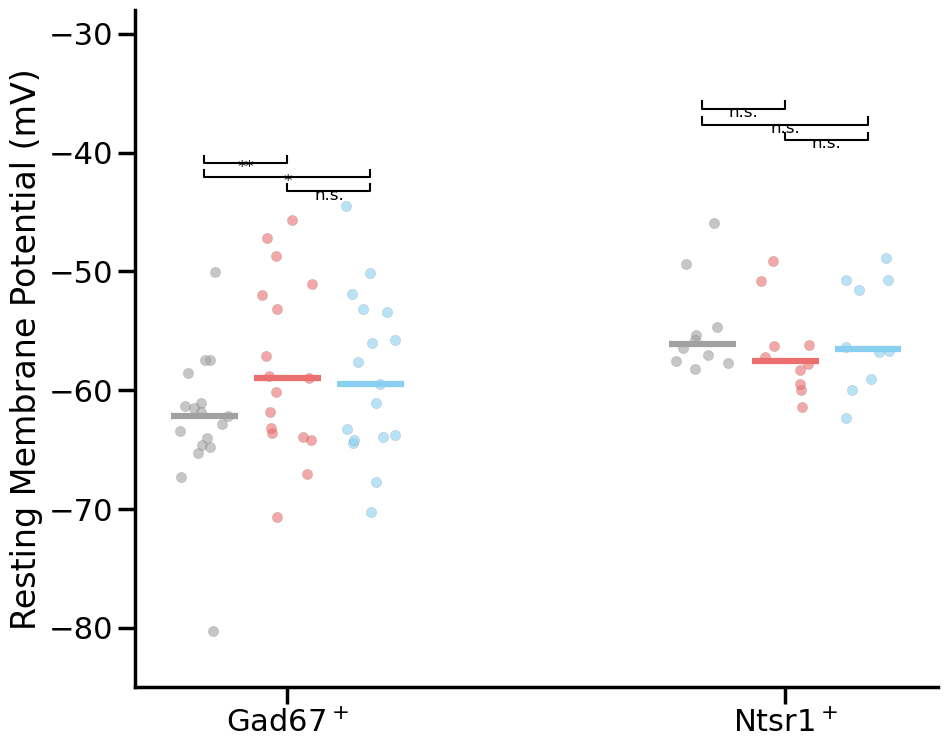

In [7]:
def plot_rmp_boxplot_grouped(pivot):
    genotypes = pivot['genotype'].unique()
    conditions = ['baseline', 'noradrenaline', 'wash']
    colors_bar = ['#A2A0A0', '#EB6F6F', '#89CFF0']

    genotype_posthoc = {}
    genotype_positions = {}

    for genotype in genotypes:
        group = pivot[pivot['genotype'] == genotype]
        if group.empty:
            continue

        long_df = group.melt(
            id_vars=['ID', 'genotype'],
            value_vars=conditions,
            var_name='condition',
            value_name='RMP'
        )

        try:
            AnovaRM(data=long_df, depvar='RMP', subject='ID', within=['condition']).fit()
            posthoc = pg.pairwise_tests(dv='RMP', within='condition', subject='ID', data=long_df, padjust='bonf')

            if 'p_corr' in posthoc.columns:
                p_col = 'p_corr'
            elif 'p-corr' in posthoc.columns:
                p_col = 'p-corr'
            elif 'p_unc' in posthoc.columns:
                p_col = 'p_unc'
            else:
                p_col = 'p-unc'

            pairs = []
            pvals = []
            for _, row in posthoc.iterrows():
                pairs.append((row['A'], row['B']))
                pvals.append(float(row[p_col]))
            genotype_posthoc[genotype] = (pairs, pvals)
        except Exception as e:
            print(f'Post-hoc error for {genotype}: {e}')

    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    n_conditions = len(conditions)
    condition_width = 0.25
    genotype_spacing = 1.5
    np.random.seed(42)

    for g_idx, genotype in enumerate(genotypes):
        group = pivot[pivot['genotype'] == genotype]
        if group.empty:
            continue

        center = g_idx * genotype_spacing
        positions = [center + (i - 1) * condition_width for i in range(n_conditions)]
        genotype_positions[genotype] = positions

        for _, row in group.iterrows():
            for i, cond in enumerate(conditions):
                if pd.notna(row[cond]):
                    xj = positions[i] + np.random.uniform(-0.08, 0.08)
                    ax.scatter(xj, row[cond], color=colors_bar[i], alpha=0.6, s=55, zorder=2, edgecolors='black', linewidths=0.1)

        for i, cond in enumerate(conditions):
            y = group[cond].dropna().values
            if len(y) > 0:
                ax.hlines(np.median(y), positions[i] - 0.1, positions[i] + 0.1, color=colors_bar[i], linewidth=4.5, zorder=3)

    for genotype in genotypes:
        if genotype in genotype_posthoc and genotype in genotype_positions:
            pairs, pvals = genotype_posthoc[genotype]
            mapping = {cond: genotype_positions[genotype][i] for i, cond in enumerate(conditions)}
            mapped = [(mapping[a], mapping[b]) for a, b in pairs if a in mapping and b in mapping]
            if mapped and pvals:
                add_significance(ax, mapped, pvals)

    centers = [i * genotype_spacing for i in range(len(genotypes))]
    labels = ['Gad67$^+$' if g == 'eGFP-Gad67' else 'Ntsr1$^+$' if g == 'Ai75D/Ntsr1' else g for g in genotypes]

    ax.set_ylim(-85, -28)
    ax.set_xticks(centers)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Resting Membrane Potential (mV)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_rmp_boxplot_grouped(pivot)

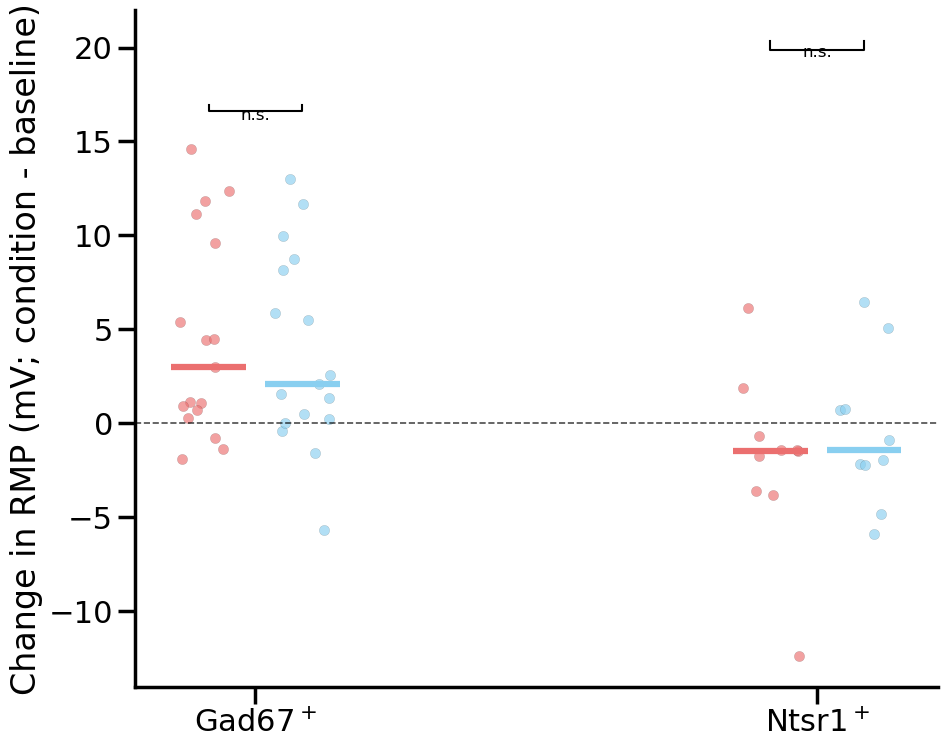

In [8]:
def plot_change_rmp_boxplot_grouped(pivot, use_absolute_change=False):
    genotypes = pivot['genotype'].unique()
    conditions = ['noradrenaline', 'wash']
    colors = ['#EB6F6F', '#89CFF0']

    plt.figure(figsize=(10, 8))
    ax = plt.gca()
    np.random.seed(42)

    genotype_spacing = 1.5
    condition_width = 0.25

    for g_idx, genotype in enumerate(genotypes):
        group = pivot[pivot['genotype'] == genotype].copy()
        if group.empty:
            continue

        for cond in conditions:
            group[f'delta_{cond}'] = group[cond] - group['baseline']
            if use_absolute_change:
                group[f'delta_{cond}'] = group[f'delta_{cond}'].abs()

        center = g_idx * genotype_spacing
        positions = [center + (i - 0.5) * condition_width for i in range(len(conditions))]

        for _, row in group.iterrows():
            for i, cond in enumerate(conditions):
                val = row.get(f'delta_{cond}', np.nan)
                if pd.notna(val):
                    xj = positions[i] + np.random.uniform(-0.08, 0.08)
                    ax.scatter(xj, val, color=colors[i], alpha=0.65, s=55, zorder=2, edgecolors='black', linewidths=0.1)

        for i, cond in enumerate(conditions):
            vals = group[f'delta_{cond}'].dropna().values
            if len(vals) > 0:
                ax.hlines(np.median(vals), positions[i] - 0.1, positions[i] + 0.1, color=colors[i], linewidth=4.5, zorder=3)

        paired = group[[f'delta_{conditions[0]}', f'delta_{conditions[1]}']].dropna()
        if len(paired) >= 3:
            res = pg.ttest(paired[f'delta_{conditions[0]}'], paired[f'delta_{conditions[1]}'], paired=True)
            p_val = float(res['p_val'].iloc[0]) if 'p_val' in res.columns else float(res['p-val'].iloc[0])
            add_significance(ax, [(positions[0], positions[1])], [p_val])

    centers = [i * genotype_spacing for i in range(len(genotypes))]
    labels = ['Gad67$^+$' if g == 'eGFP-Gad67' else 'Ntsr1$^+$' if g == 'Ai75D/Ntsr1' else g for g in genotypes]

    ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
    ax.set_xticks(centers)
    ax.set_xticklabels(labels)
    ax.set_ylabel('|Change in RMP| (mV)' if use_absolute_change else 'Change in RMP (mV; condition - baseline)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_change_rmp_boxplot_grouped(pivot)

In [9]:
def extract_rmp_per_sweep(abf_file):
    """
    Extract resting membrane potential from each individual sweep in an ABF file.
    Returns a list of RMP values, one per sweep.
    """
    try:
        abf = pyabf.ABF(abf_file)
        sweep_rmp_values = []
        
        # Use last 10 sweeps (or all if fewer than 10)
        sweep_indices = abf.sweepList[-10:] if len(abf.sweepList) > 10 else abf.sweepList
        
        for sweep in sweep_indices:
            abf.setSweep(sweep)
            first_100ms = abf.sweepY[:int(0.1 * abf.dataRate)]  # First 100 ms
            sweep_rmp = np.mean(first_100ms)
            sweep_rmp_values.append(sweep_rmp)
        
        return sweep_rmp_values
    
    except Exception as e:
        print(f"Error processing {abf_file}: {e}")
        return []

def create_rmp_per_sweep_dataframe(csv_file_path):
    """
    Create a dataframe with RMP values for each individual sweep.
    """
    # Load the existing results file
    results_df = pd.read_excel(csv_file_path)
    
    # Filter out excluded files
    filtered_df = results_df[results_df['comment'].str.strip().str.lower() != "exclude"]
    
    # Create list to store all sweep data
    all_sweep_data = []
    
    # Process each file
    for i, row in filtered_df.iterrows():
        if pd.notna(row['filepath']) and os.path.exists(row['filepath']):
            print(f"Processing file {i+1}/{len(filtered_df)}: {row['filepath']}")
            
            # Extract RMP from each sweep
            sweep_rmp_values = extract_rmp_per_sweep(row['filepath'])
            
            # Add each sweep as a separate row
            for sweep_idx, rmp_value in enumerate(sweep_rmp_values):
                all_sweep_data.append({
                    'ID': row['ID'],
                    'genotype': row['genotype'],
                    'condition': row['condition'],
                    'sweep_number': sweep_idx + 1,
                    'RMP': rmp_value,
                    'filepath': row['filepath']
                })
        else:
            print(f"File not found: {row.get('filepath', 'N/A')}")
    
    # Convert to DataFrame
    sweep_df = pd.DataFrame(all_sweep_data)
    
    print(f"Created dataframe with {len(sweep_df)} individual sweep measurements")
    print(f"From {len(filtered_df)} cells across {len(sweep_df['genotype'].unique())} genotypes")
    
    return sweep_df

sweep_df = create_rmp_per_sweep_dataframe(MASTER_FILE)
sweep_df.head()

Processing file 1/81: /Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/gad/24.03.2025 M1/2025_03_24_0002.abf
Processing file 2/81: /Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/gad/24.03.2025 M1/2025_03_24_0003.abf
Processing file 3/81: /Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/gad/24.03.2025 M1/2025_03_24_0004.abf
Processing file 4/81: /Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/gad/24.03.2025 M1/2025_03_24_0007.abf
Processing file 5/81: /Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/gad/24.03.2025 M1/2025_03_24_0008.abf
Processing file 6/81: /Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/gad/24.03.2025 M1/2025_03_24_0009.abf
Processing file 7/81: /Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/gad/24.03.2025 M1/2025_03_24_0012.abf
Processing file 8/81: /Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/gad/24.03.2025 M1/2025_03_24_0013.abf
Processing file 9/81: /Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/gad/24.03.2025 M1/2025_03_24_0

,ID,genotype,condition,sweep_number,RMP,filepath
0,1,eGFP-Gad67,baseline,1,-64.013748,/Volumes/joeschgrp/Group Members/Rima/Ephys_NE...
1,1,eGFP-Gad67,baseline,2,-64.737183,/Volumes/joeschgrp/Group Members/Rima/Ephys_NE...
2,1,eGFP-Gad67,baseline,3,-64.742020,/Volumes/joeschgrp/Group Members/Rima/Ephys_NE...
3,1,eGFP-Gad67,baseline,4,-64.224792,/Volumes/joeschgrp/Group Members/Rima/Ephys_NE...
4,1,eGFP-Gad67,baseline,5,-65.768440,/Volumes/joeschgrp/Group Members/Rima/Ephys_NE...


/var/folders/pj/c6v4sq5n3pn_r1qk76bj_z3c0000gn/T/ipykernel_11860/2385075487.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


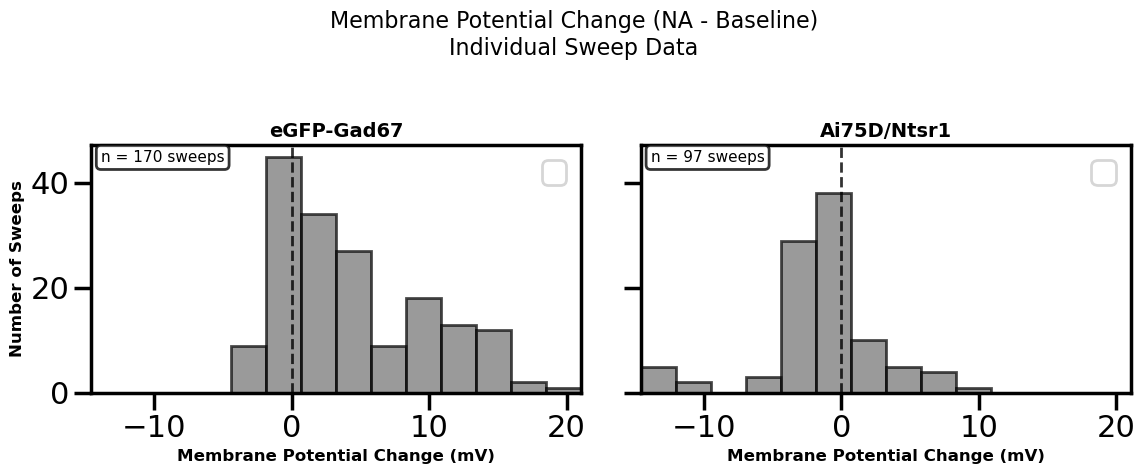

In [10]:
# Plot histogram of membrane potential change using individual sweep data
from scipy import stats

def plot_delta_rmp_per_sweep_histogram(sweep_df):
    """
    Plot histogram of membrane potential change (Noradrenaline - baseline) 
    using individual sweep data for each genotype, with centered x-axes.
    Uses the same sweep extraction basis as the existing functions.
    """
    genotypes = sweep_df['genotype'].unique()
    conditions = ['baseline', 'Noradrenaline']
    
    # First, calculate all delta values to determine common x-axis range
    all_deltas = []
    genotype_deltas = {}
    
    for genotype in genotypes:
        genotype_data = sweep_df[sweep_df['genotype'] == genotype]
        cell_deltas = []
        
        # For each cell, calculate delta for each sweep
        for cell_id in genotype_data['ID'].unique():
            cell_data = genotype_data[genotype_data['ID'] == cell_id]
            
            baseline_sweeps = cell_data[cell_data['condition'] == 'baseline']['RMP'].values
            na_sweeps = cell_data[cell_data['condition'] == 'Noradrenaline']['RMP'].values
            
            # Calculate mean baseline and mean NA for this cell, then delta
            if len(baseline_sweeps) > 0 and len(na_sweeps) > 0:
                baseline_mean = np.mean(baseline_sweeps)
                # For each NA sweep, calculate delta from baseline mean
                for na_val in na_sweeps:
                    delta = na_val - baseline_mean
                    cell_deltas.append(delta)
        
        genotype_deltas[genotype] = cell_deltas
        all_deltas.extend(cell_deltas)
    
    # Determine common x-axis range for centering
    if all_deltas:
        x_min = min(all_deltas) - 1
        x_max = max(all_deltas) + 1
        bins = np.linspace(x_min, x_max, 15)
    else:
        print("No data to plot")
        return
    
    # Create subplots - one for each genotype
    fig, axes = plt.subplots(1, len(genotypes), figsize=(12, 5), sharey=True)
    
    # Color palette for conditions
    colors = ["#908E8E", "#EB6F6F"]  
    
    for idx, genotype in enumerate(genotypes):
        ax = axes[idx]
        delta_data = genotype_deltas[genotype]
        
        if len(delta_data) > 0:
            # Plot histogram
            ax.hist(delta_data, bins=bins, color="#707070", edgecolor='black', 
                   alpha=0.7, density=False)
            
            # Add vertical line at zero (centered)
            ax.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.8)
            
            # Add sample size to plot
            ax.text(0.02, 0.98, f'n = {len(delta_data)} sweeps', 
                   transform=ax.transAxes, fontsize=11, 
                   verticalalignment='top', 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
            
            ax.set_title(f"{genotype}", fontsize=14, fontweight='bold')
            ax.set_xlabel("Membrane Potential Change (mV)", fontsize=12, fontweight='bold')
            ax.legend()
            # ax.grid(True, alpha=0.3)
            
            # Set same x-axis range for all plots (centered)
            ax.set_xlim(x_min, x_max)
            
    # Set y-label only on leftmost plot
    axes[0].set_ylabel("Number of Sweeps", fontsize=12, fontweight='bold')
    
    plt.suptitle("Membrane Potential Change (NA - Baseline)\nIndividual Sweep Data", 
                 fontsize=16)
    plt.tight_layout()
    plt.show()

plot_delta_rmp_per_sweep_histogram(sweep_df)

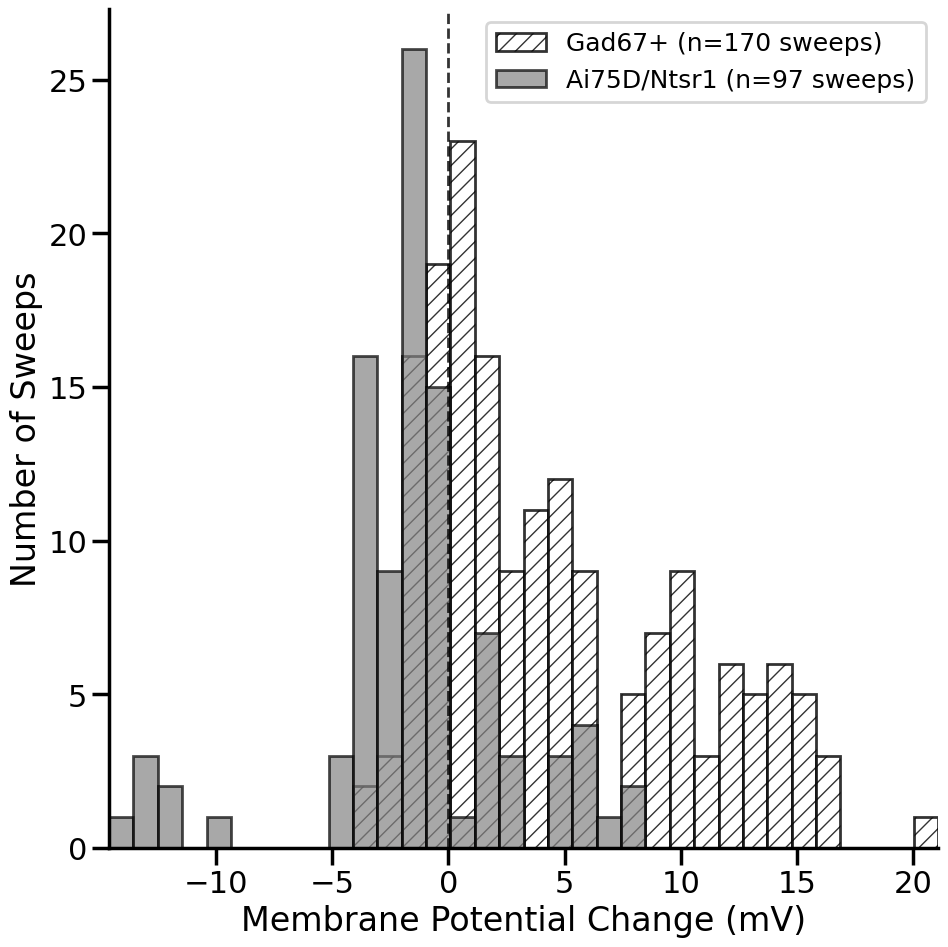

In [11]:
from scipy import stats

def plot_delta_rmp_per_sweep_histogram_single(sweep_df):
    """
    Plot histogram of membrane potential change (Noradrenaline - baseline) 
    using individual sweep data in a single figure with different patterns for each genotype.
    Uses the same sweep extraction basis as the existing functions.
    """
    genotypes = sweep_df['genotype'].unique()
    conditions = ['baseline', 'Noradrenaline']
    
    # First, calculate all delta values to determine common x-axis range
    all_deltas = []
    genotype_deltas = {}
    
    for genotype in genotypes:
        genotype_data = sweep_df[sweep_df['genotype'] == genotype]
        cell_deltas = []
        
        # For each cell, calculate delta for each sweep
        for cell_id in genotype_data['ID'].unique():
            cell_data = genotype_data[genotype_data['ID'] == cell_id]
            
            baseline_sweeps = cell_data[cell_data['condition'] == 'baseline']['RMP'].values
            na_sweeps = cell_data[cell_data['condition'] == 'Noradrenaline']['RMP'].values
            
            # Calculate mean baseline and mean NA for this cell, then delta
            if len(baseline_sweeps) > 0 and len(na_sweeps) > 0:
                baseline_mean = np.mean(baseline_sweeps)
                # For each NA sweep, calculate delta from baseline mean
                for na_val in na_sweeps:
                    delta = na_val - baseline_mean
                    cell_deltas.append(delta)
        
        genotype_deltas[genotype] = cell_deltas
        all_deltas.extend(cell_deltas)
    
    # Determine common x-axis range for centering
    if all_deltas:
        x_min = min(all_deltas) - 1
        x_max = max(all_deltas) + 1
        bins = np.linspace(x_min, x_max, 35)
    else:
        print("No data to plot")
        return
    
    # Create single figure
    plt.figure(figsize=( 10, 10))
   
    
    # Define patterns and colors for each genotype
    patterns = {
        'Ai75D\\Ntsr1': None,   # Striped pattern for GAD67
        'eGFP-Gad67': '//'  # No fill (empty) for NTSR1
    }
    # Use transparent fill for histogram bars
    colors = {
        'Ai75D\\Ntsr1':  'gray',
        'eGFP-Gad67': 'white'  
    }
    
    edge_colors = {
        'Ai75D\\Ntsr1': 'black',
        'eGFP-Gad67': 'black'
    }
    
    alphas = {
        'Ai75D\\Ntsr1': 0.6,
        'eGFP-Gad67': 0.8  
    }
    
    
    # Plot histograms for each genotype
    for genotype in genotypes:
        delta_data = genotype_deltas[genotype]
        
        if len(delta_data) > 0:
            plt.hist(delta_data, 
                    bins=bins, 
                    label=f'{genotype} (n={len(delta_data)} sweeps)',
                    color=colors.get(genotype, "#848383"),
                    edgecolor=edge_colors.get(genotype, 'black'),
                    hatch=patterns.get(genotype, None),
                    alpha=alphas.get(genotype, 0.7),
                    linewidth=2)
    
    # Add vertical line at zero (centered)
    plt.axvline(0, color='black', linestyle='--', linewidth=2, alpha=0.8)
    
    # Formatting
    plt.xlabel("Membrane Potential Change (mV)")
    plt.ylabel("Number of Sweeps")
    #plt.title("Membrane Potential Change (NA - Baseline)\nIndividual Sweep Data")
    # Custom legend labels
    handles, labels = plt.gca().get_legend_handles_labels()
    custom_labels = []
    for label in labels:
        if 'Ai75D\\Ntsr1' in label:
            custom_labels.append(label.replace('Ai75D\\Ntsr1', 'Ntsr1+'))
        elif 'eGFP-Gad67' in label:
            custom_labels.append(label.replace('eGFP-Gad67', 'Gad67+'))
        else:
            custom_labels.append(label)

    plt.legend(custom_labels, fontsize=18)
    plt.xlim(x_min, x_max)
    
    # Remove top and right spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig("rmp_change_histogram.pdf", dpi=300)
    plt.show()

# Usage with your sweep_df
plot_delta_rmp_per_sweep_histogram_single(sweep_df)

eGFP-Gad67 vs 0: p=0.003174 (n=17)
Ai75D/Ntsr1 vs 0: p=0.2412 (n=10)
Between-genotype delta comparison: p=0.003979


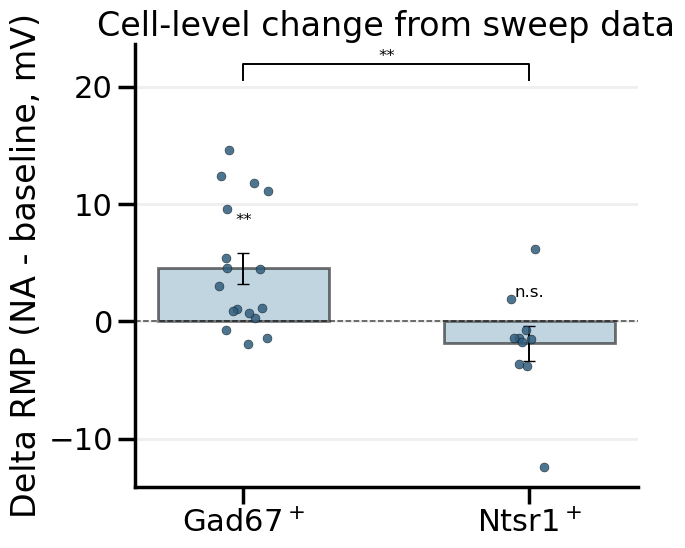

In [12]:
from scipy import stats

def plot_delta_rmp_bar_from_sweeps(sweep_df):
    """
    Plot NA-baseline change as a bar plot using one value per cell.
    This avoids pseudo-replication from treating each sweep as independent.
    """
    required = {'ID', 'genotype', 'condition', 'RMP'}
    missing = required - set(sweep_df.columns)
    if missing:
        raise KeyError(f"sweep_df is missing required columns: {missing}")

    # 1) Collapse sweeps to one mean RMP per cell per condition
    cell_means = (
        sweep_df
        .groupby(['ID', 'genotype', 'condition'], as_index=False)['RMP']
        .mean()
    )

    # 2) Compute one delta per cell
    wide = (
        cell_means
        .pivot_table(index=['ID', 'genotype'], columns='condition', values='RMP')
        .reset_index()
    )

    if 'baseline' not in wide.columns or 'Noradrenaline' not in wide.columns:
        raise KeyError("Need both 'baseline' and 'Noradrenaline' conditions in sweep_df")

    wide['delta_NA'] = wide['Noradrenaline'] - wide['baseline']
    delta_df = wide.dropna(subset=['delta_NA']).copy()

    if delta_df.empty:
        print('No paired baseline/NA cell data found.')
        return delta_df

    genotypes = list(delta_df['genotype'].unique())
    x = np.arange(len(genotypes), dtype=float)

    fig, ax = plt.subplots(figsize=(7, 6))

    means = []
    sems = []
    grouped_values = []

    for genotype in genotypes:
        vals = delta_df.loc[delta_df['genotype'] == genotype, 'delta_NA'].values
        grouped_values.append(vals)
        means.append(np.mean(vals))
        sems.append(np.std(vals, ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0)

    # Bars + error bars
    ax.bar(x, means, width=0.6, color='#8FB3C9', edgecolor='black', alpha=0.55, zorder=1)
    ax.errorbar(x, means, yerr=sems, fmt='none', ecolor='black', capsize=4, linewidth=1.4, zorder=3)

    # Cell-level points
    np.random.seed(42)
    for i, vals in enumerate(grouped_values):
        jitter = np.random.uniform(-0.09, 0.09, size=len(vals))
        ax.scatter(np.full(len(vals), x[i]) + jitter, vals, s=42, color='#2F5D7C',
                   edgecolor='black', linewidth=0.3, alpha=0.85, zorder=4)

    # One-sample test vs zero per genotype (does NA shift from baseline?)
    y_all = np.concatenate(grouped_values)
    y_span = max(1.0, float(np.nanmax(y_all) - np.nanmin(y_all)))
    top_base = float(np.nanmax(np.r_[means, y_all]))

    for i, vals in enumerate(grouped_values):
        if len(vals) >= 3:
            p = stats.ttest_1samp(vals, 0, nan_policy='omit').pvalue
            if p < 0.001:
                star = '***'
            elif p < 0.01:
                star = '**'
            elif p < 0.05:
                star = '*'
            else:
                star = 'n.s.'
            ax.text(x[i], means[i] + sems[i] + 0.08 * y_span, star,
                    ha='center', va='bottom', fontsize=12)
            print(f"{genotypes[i]} vs 0: p={p:.4g} (n={len(vals)})")

    # Between-genotype comparison on per-cell deltas (Welch t-test)
    if len(grouped_values) == 2 and len(grouped_values[0]) >= 3 and len(grouped_values[1]) >= 3:
        p_between = stats.ttest_ind(grouped_values[0], grouped_values[1], equal_var=False, nan_policy='omit').pvalue
        y = top_base + 0.22 * y_span
        h = 0.05 * y_span
        ax.plot([x[0], x[0], x[1], x[1]], [y, y + h, y + h, y], color='black', linewidth=1.4)
        if p_between < 0.001:
            label = '***'
        elif p_between < 0.01:
            label = '**'
        elif p_between < 0.05:
            label = '*'
        else:
            label = 'n.s.'
        ax.text(np.mean([x[0], x[1]]), y + h * 1.05, label, ha='center', va='bottom', fontsize=12)
        print(f"Between-genotype delta comparison: p={p_between:.4g}")

    # Formatting
    pretty = []
    for g in genotypes:
        if g == 'eGFP-Gad67':
            pretty.append('Gad67$^+$')
        elif g == 'Ai75D/Ntsr1':
            pretty.append('Ntsr1$^+$')
        else:
            pretty.append(g)

    ax.axhline(0, linestyle='--', linewidth=1.1, color='black', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(pretty)
    ax.set_ylabel('Delta RMP (NA - baseline, mV)')
    ax.set_title('Cell-level change from sweep data')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)

    plt.tight_layout()
    plt.show()

    return delta_df

# Run this on your current sweep dataframe
delta_cell_df = plot_delta_rmp_bar_from_sweeps(sweep_df)

/var/folders/pj/c6v4sq5n3pn_r1qk76bj_z3c0000gn/T/ipykernel_11860/1756195327.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


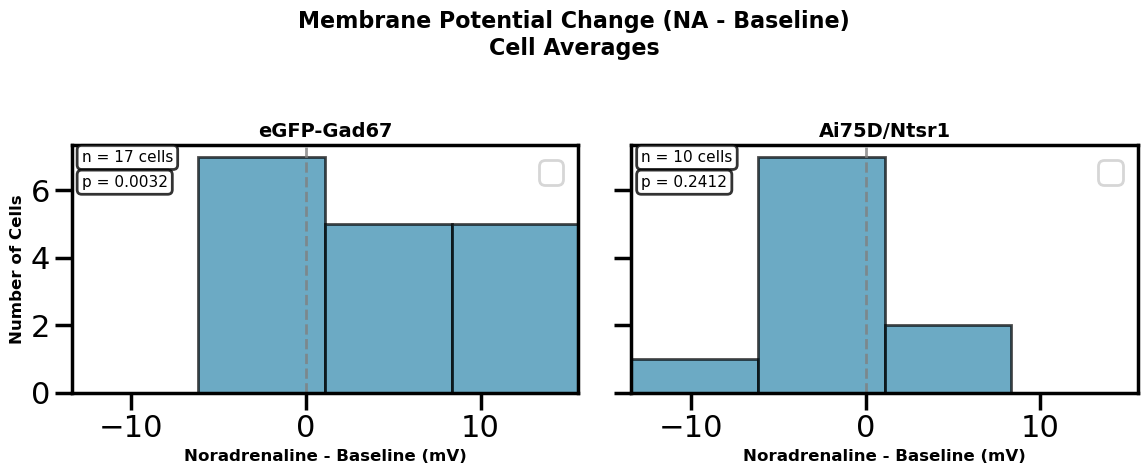

In [13]:
# Plot histogram of membrane potential change using cell averages
from scipy import stats

def plot_delta_rmp_cell_averages(results_csv):
    """
    Plot histogram of membrane potential change (Noradrenaline - baseline) 
    using cell averages for each genotype, with centered x-axes.
    """
    # Load and filter data
    results_df = pd.read_excel(results_csv)
    filtered_df = results_df[results_df['comment'].str.strip().str.lower() != "exclude"]
    
    # Create pivot table for RMP data (same as your existing pivot)
    pivot = filtered_df.pivot_table(
        index=['ID', 'genotype'],
        columns='condition',
        values='RMP'
    ).reset_index()
    
    genotypes = pivot['genotype'].unique()
    
    # Calculate delta values for each genotype
    all_deltas = []
    genotype_deltas = {}
    
    for genotype in genotypes:
        # Select rows for this genotype where both baseline and Noradrenaline are not NaN
        df_sub = pivot[(pivot['genotype'] == genotype) & 
                       pivot['baseline'].notna() & 
                       pivot['Noradrenaline'].notna()]
        
        # Calculate delta RMP (Noradrenaline - baseline) for each cell
        delta_rmp = df_sub['Noradrenaline'] - df_sub['baseline']
        
        genotype_deltas[genotype] = delta_rmp.values
        all_deltas.extend(delta_rmp.values)
    
    # Determine common x-axis range for centering
    if all_deltas:
        x_min = min(all_deltas) - 1
        x_max = max(all_deltas) + 1
        bins = np.linspace(x_min, x_max, 5)
    else:
        print("No data to plot")
        return
    
    # Create subplots - one for each genotype
    fig, axes = plt.subplots(1, len(genotypes), figsize=(12, 5), sharey=True)
    
    if len(genotypes) == 1:
        axes = [axes]
    
    for idx, genotype in enumerate(genotypes):
        ax = axes[idx]
        delta_data = genotype_deltas[genotype]
        
        if len(delta_data) > 0:
            # Plot histogram
            ax.hist(delta_data, bins=bins, color='#2E86AB', edgecolor='black', 
                   alpha=0.7, density=False)
        
            # Add vertical line at zero
            ax.axvline(0, color='gray', linestyle='--', linewidth=2, alpha=0.8)

            
            # Add sample size to plot
            ax.text(0.02, 0.98, f'n = {len(delta_data)} cells', 
                   transform=ax.transAxes, fontsize=11, 
                   verticalalignment='top', 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            # Perform t-test against zero
            t_stat, p_val = stats.ttest_1samp(delta_data, 0)
            ax.text(0.02, 0.88, f'p = {p_val:.4f}', 
                   transform=ax.transAxes, fontsize=11, 
                   verticalalignment='top', 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            ax.set_title(f"{genotype}", fontsize=14, fontweight='bold')
            ax.set_xlabel("Noradrenaline - Baseline (mV)", fontsize=12, fontweight='bold')
            ax.legend()
            
            # Set same x-axis range for all plots (centered)
            ax.set_xlim(x_min, x_max)
            
    # Set y-label only on leftmost plot
    axes[0].set_ylabel("Number of Cells", fontsize=12, fontweight='bold')
    
    plt.suptitle("Membrane Potential Change (NA - Baseline)\nCell Averages", 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run the function
plot_delta_rmp_cell_averages(MASTER_FILE)